# 02 Code checks

Imports the model, dataset, sampler, loss and mixing code straight from `notebook.py` and prints
the numbers quoted in the docs. CPU only.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("SG10_DATA_ROOT", os.path.abspath("../data/shift-guard-10-robust-image-classification-challenge"))
ROOT = os.environ["SG10_DATA_ROOT"]
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
print("data found:", os.path.isdir(ROOT))
import math, random, torch, torch.nn as nn, torch.nn.functional as F
import notebook as nb   # the competition script itself
from notebook import (WideResNet, ShiftGuard10Dataset, BalancedSoftmaxLoss, cutmix_data, mixup_data,
                      Cutout, get_train_transforms, get_tta_transform, get_val_transforms,
                      CLASS_NAMES, CIFAR_MEAN, CIFAR_STD)
torch.manual_seed(0); np.random.seed(0); random.seed(0)

data found: True


## WRN-28-10: parameters and shapes

In [2]:
model = WideResNet().eval()
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
parts = {n: sum(p.numel() for p in getattr(model, n).parameters()) for n in ["conv1", "group1", "group2", "group3", "bn", "fc"]}
print(parts)
x = torch.randn(1, 3, 32, 32)
with torch.no_grad():
    for name in ["conv1", "group1", "group2", "group3"]:
        x = getattr(model, name)(x); print(f"{name:7s} -> {tuple(x.shape)}")
    print("output  ->", tuple(model(torch.randn(1, 3, 32, 32)).shape))

parameters: 36,479,194
{'conv1': 432, 'group1': 1640672, 'group2': 6968000, 'group3': 27862400, 'bn': 1280, 'fc': 6410}
conv1   -> (1, 16, 32, 32)
group1  -> (1, 160, 32, 32)
group2  -> (1, 320, 16, 16)
group3  -> (1, 640, 8, 8)
output  -> (1, 10)


In [3]:
macs = 0
def hook(m, i, o):
    global macs
    if isinstance(m, nn.Conv2d): macs += o.numel() * m.in_channels * m.kernel_size[0] * m.kernel_size[1]
    if isinstance(m, nn.Linear): macs += m.in_features * m.out_features
hs = [m.register_forward_hook(hook) for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
with torch.no_grad(): model(torch.randn(1, 3, 32, 32))
for h in hs: h.remove()
print(f"multiply-adds per image: {macs/1e9:.2f} billion")
c = model.group2[1].conv1
print("Kaiming fan_out std, expected", round(math.sqrt(2/(320*9)), 4), "measured", round(c.weight.std().item(), 4))

multiply-adds per image: 5.24 billion
Kaiming fan_out std, expected 0.0264 measured 0.0263


## The 95/5 class-wise split

In [4]:
tr = ShiftGuard10Dataset(ROOT, "train", None, val_ratio=0.05, seed=42)
va = ShiftGuard10Dataset(ROOT, "val", None, val_ratio=0.05, seed=42)
print(len(tr), len(va), "overlap:", len(set(tr.image_ids) & set(va.image_ids)))
pd.DataFrame({"train": tr.get_class_counts(), "val": va.get_class_counts()}, index=CLASS_NAMES)

27930 1470 overlap: 0


,train,val
airplane,4750,250
automobile,4750,250
bird,4750,250
cat,4750,250
deer,3800,200
dog,3800,200
frog,475,25
horse,475,25
ship,285,15
truck,95,5


## The sqrt-inverse sampler (real sampler, one simulated epoch)

In [5]:
counts = tr.get_class_counts()
idx = list(iter(tr.get_sampler()))
lab = np.array(tr.labels)[idx]
df = pd.DataFrame({
    "n": counts,
    "natural %": 100 * counts / counts.sum(),
    "sampled % (formula)": 100 * np.sqrt(counts) / np.sqrt(counts).sum(),
    "sampled % (simulated)": [100 * (lab == k).mean() for k in range(10)],
    "draws per image": [(lab == k).sum() / counts[k] for k in range(10)],
    "% of images drawn": [100 * len(set(np.array(idx)[lab == k])) / counts[k] for k in range(10)],
}, index=CLASS_NAMES).round(2)
df

,n,natural %,sampled % (formula),sampled % (simulated),draws per image,% of images drawn
airplane,4750,17.01,14.69,14.52,0.85,57.26
automobile,4750,17.01,14.69,14.99,0.88,57.75
bird,4750,17.01,14.69,14.48,0.85,57.85
cat,4750,17.01,14.69,14.82,0.87,57.94
deer,3800,13.61,13.14,13.29,0.98,62.29
dog,3800,13.61,13.14,12.94,0.95,60.95
frog,475,1.70,4.65,4.46,2.63,90.32
horse,475,1.70,4.65,4.68,2.75,93.68
ship,285,1.02,3.60,3.73,3.66,97.19
truck,95,0.34,2.08,2.08,6.13,100.00


In [6]:
for B in (128, 512):   # 128 = training version, 512 = final file default
    q = np.sqrt(counts[9]) / np.sqrt(counts).sum(); p = counts[9] / counts.sum()
    print(f"batch {B}: P(no truck) natural {(1-p)**B:.3f}, sampler {(1-q)**B:.3f}")

batch 128: P(no truck) natural 0.647, sampler 0.068
batch 512: P(no truck) natural 0.175, sampler 0.000


## Balanced Softmax

In [7]:
crit = BalancedSoftmaxLoss(counts)
print("log prior:", {k: round(float(v), 3) for k, v in zip(CLASS_NAMES, crit.log_freq)})
print("equal raw logits -> training softmax:", F.softmax(crit.log_freq[None], 1).numpy().round(4))
q = np.sqrt(counts) / np.sqrt(counts).sum(); pi = counts / counts.sum()
bias = np.log(q) - np.log(pi); bias -= bias.mean()
print("theoretical raw-logit tilt with sampler + raw counts:", {k: round(float(v), 2) for k, v in zip(CLASS_NAMES, bias)})
print("truck vs cat odds factor:", round(float(np.exp(bias[9] - bias[3])), 2))

log prior: {'airplane': -1.772, 'automobile': -1.772, 'bird': -1.772, 'cat': -1.772, 'deer': -1.995, 'dog': -1.995, 'frog': -4.074, 'horse': -4.074, 'ship': -4.585, 'truck': -5.684}
equal raw logits -> training softmax: [[0.1701 0.1701 0.1701 0.1701 0.1361 0.1361 0.017  0.017  0.0102 0.0034]]
theoretical raw-logit tilt with sampler + raw counts: {'airplane': -0.59, 'automobile': -0.59, 'bird': -0.59, 'cat': -0.59, 'deer': -0.48, 'dog': -0.48, 'frog': 0.56, 'horse': 0.56, 'ship': 0.82, 'truck': 1.37}
truck vs cat odds factor: 7.07


In [8]:
# label smoothing inside Balanced Softmax: a perfectly fitted cat image
rows = {}
for eps in (0.0, 0.05, 0.1, 0.15, 0.2):
    z = torch.zeros(1, 10, requires_grad=True); opt = torch.optim.LBFGS([z], max_iter=500)
    def closure():
        opt.zero_grad(); l = F.cross_entropy(z + crit.log_freq, torch.tensor([3]), label_smoothing=eps); l.backward(); return l
    for _ in range(5): opt.step(closure)
    p = F.softmax(z, 1)[0].detach().numpy()
    rows[eps] = {"cat": p[3], "truck": p[9], "ship": p[8], "argmax": CLASS_NAMES[p.argmax()]}
pd.DataFrame(rows).T

,cat,truck,ship,argmax
0.00,1.0,0.0,0.0,cat
0.05,0.674514,0.17658,0.058853,cat
0.10,0.496862,0.272921,0.090992,cat
0.15,0.384873,0.333707,0.111232,cat
0.20,0.307887,0.375468,0.125156,truck


## Cutout and CutMix on real images

In [ ]:
# Shows competition images. The saved output is removed in the repo (no redistribution); run locally to see it.
val_tf = get_val_transforms()
imgs = torch.stack([val_tf(tr[i][0]) for i in range(0, 27930, 3500)][:8])
def show(t):
    x = t * torch.tensor(CIFAR_STD)[:, None, None] + torch.tensor(CIFAR_MEAN)[:, None, None]
    return x.clamp(0, 1).permute(1, 2, 0).numpy()
cut = torch.stack([Cutout(16)(im) for im in imgs])
mixed, ya, yb, lam = cutmix_data(imgs, torch.arange(8), 1.0)
fig, axes = plt.subplots(3, 8, figsize=(9, 3.6))
for k in range(8):
    for r, src in enumerate([imgs, cut, mixed]):
        axes[r, k].imshow(show(src[k])); axes[r, k].axis("off")
axes[0, 0].set_title("original", fontsize=8, loc="left"); axes[1, 0].set_title("Cutout 16", fontsize=8, loc="left")
axes[2, 0].set_title(f"CutMix, lambda = {lam:.2f}", fontsize=8, loc="left")
plt.tight_layout(); plt.show()
print("Cutout grey in pixel values:", [round(m * 255, 1) for m in CIFAR_MEAN])

In [10]:
gaps = []
rng = random.Random(1); nrng = np.random.RandomState(1)
for _ in range(5000):
    lam0 = nrng.beta(1, 1); cw = int(32 * math.sqrt(1 - lam0)); cx, cy = rng.randint(0, 31), rng.randint(0, 31)
    x1, y1, x2, y2 = max(0, cx - cw // 2), max(0, cy - cw // 2), min(32, cx + cw // 2), min(32, cy + cw // 2)
    gaps.append(abs((1 - (y2 - y1) * (x2 - x1) / 1024) - lam0))
print(f"CutMix: sampled vs recomputed lambda differ by {np.mean(gaps):.2f} on average (90th pct {np.percentile(gaps, 90):.2f})")

CutMix: sampled vs recomputed lambda differ by 0.20 on average (90th pct 0.45)


## Training augmentation and TTA views of one image

In [ ]:
# Shows competition images. The saved output is removed in the repo (no redistribution); run locally to see it.
img = tr[100][0]
train_tf, tta_tf = get_train_transforms(), get_tta_transform()
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for k in range(8):
    axes[0, k].imshow(show(train_tf(img))); axes[0, k].axis("off")
    axes[1, k].imshow(show(tta_tf(img))); axes[1, k].axis("off")
axes[0, 0].set_title("training views", fontsize=8, loc="left"); axes[1, 0].set_title("TTA views", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## Learning-rate schedule

Real settings from `notebook.py`: base LR 0.1, 450 epochs, warmup 5, SWA from epoch 360 with
SWALR to 0.005 (anneal 10 epochs).

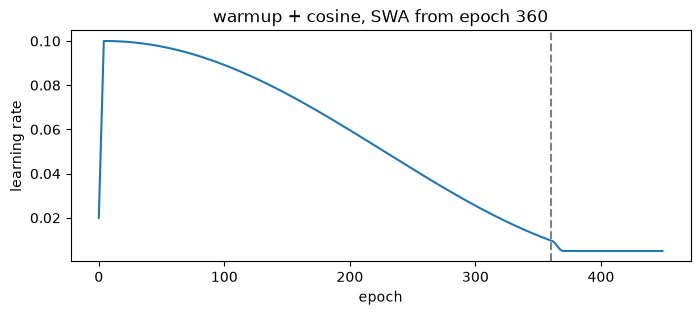

{0: 0.02, 4: 0.1, 5: 0.1, 100: 0.08917, 359: 0.00997, 360: 0.00976, 365: 0.00738, 370: 0.005, 449: 0.005}


In [12]:
from torch.optim.swa_utils import SWALR
p = nn.Parameter(torch.zeros(1)); opt = torch.optim.SGD([p], lr=0.1, momentum=0.9, nesterov=True)
def lr_lambda(e, E=450, W=5):
    return (e + 1) / W if e < W else 0.5 * (1 + math.cos(math.pi * (e - W) / (E - W)))
sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda); swa = SWALR(opt, swa_lr=0.005)
lrs = []
for e in range(450):
    lrs.append(opt.param_groups[0]["lr"]); opt.step()
    (swa if e >= 360 else sch).step()
plt.figure(figsize=(8, 3)); plt.plot(lrs); plt.axvline(360, ls="--", c="gray")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title("warmup + cosine, SWA from epoch 360"); plt.show()
print({e: round(lrs[e], 5) for e in (0, 4, 5, 100, 359, 360, 365, 370, 449)})

## How noisy is validation macro F1?

In [13]:
from sklearn.metrics import f1_score
y = np.array(va.labels)
pred = y.copy(); pred[np.where(y == 9)[0][0]] = 1
print("one truck wrong, rest perfect: macro F1", round(f1_score(y, pred, average="macro"), 4), " accuracy", round((pred == y).mean(), 4))
rng = np.random.default_rng(0); scores = []
for _ in range(2000):
    p = y.copy(); wrong = rng.random(len(y)) > 0.95
    p[wrong] = (y[wrong] + rng.integers(1, 10, wrong.sum())) % 10
    scores.append(f1_score(y, p, average="macro"))
print("simulated 5% random errors: macro F1 std", round(float(np.std(scores)), 4))

one truck wrong, rest perfect: macro F1 0.9887  accuracy 0.9993


simulated 5% random errors: macro F1 std 0.0151
